In [1]:
# Importacion de librerias 
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("server_logs.csv") # Lectura del csv utilizando la funcion de pandas .read_csv()
df.info()                           # Imprime toda la informacion del DataFrame (columnas, tipo de datos, uso de memoria)

<class 'pandas.DataFrame'>
RangeIndex: 5795 entries, 0 to 5794
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   timestamp_event  5795 non-null   str  
 1   received_at      5795 non-null   str  
 2   service_name     5795 non-null   str  
 3   severity         5795 non-null   str  
 4   message          5795 non-null   str  
 5   trace_id         5795 non-null   str  
 6   request_id       5795 non-null   str  
 7   method           5795 non-null   str  
 8   endpoint         5795 non-null   str  
 9   status_code      5795 non-null   int64
 10  latency_ms       5795 non-null   int64
 11  host             5795 non-null   str  
 12  env              5795 non-null   str  
 13  region           5795 non-null   str  
 14  log_type         5795 non-null   str  
dtypes: int64(2), str(13)
memory usage: 679.2 KB


In [2]:
df.head() # Devuelve las 5 primeras filas de cada columna

,timestamp_event,received_at,service_name,severity,message,trace_id,request_id,method,endpoint,status_code,latency_ms,host,env,region,log_type
0,2026-01-10T00:02:39.029160Z,2026-01-10T00:02:39.097160Z,orders-service,INFO,Request completed,bd8e6ebe717b4c43ba5e72e1668641a8,e6b3009adcad,GET,/orders/create,200,99,orders-service-pod-03,prod,sa-east-1,request
1,2026-01-10T00:02:46.081021Z,2026-01-10T00:02:46.196021Z,api-gateway,INFO,Background job completed,40ac5ff97bae43d5b8045484725e0aca,e2aa1cccd1cf,GET,/health,200,122,api-gateway-pod-01,prod,sa-east-1,request
2,2026-01-10T00:04:01.648849Z,2026-01-10T00:04:01.718849Z,notification-service,WARN,Rate limit nearing threshold,c048b378759a4c54a6f7d7251a6acc88,c74106ca8581,POST,/notify/sms,200,646,notification-service-pod-03,prod,sa-east-1,request
3,2026-01-10T00:05:08.148346Z,2026-01-10T00:05:08.236346Z,api-gateway,INFO,Background job completed,072169f708c84227986bfda9f9657bdc,bf10fa3609bd,GET,/checkout,200,127,api-gateway-pod-03,prod,sa-east-1,request
4,2026-01-10T00:05:19.590837Z,2026-01-10T00:05:19.632837Z,inventory-service,INFO,Health check OK,e76a214131d24a4ea1acf389362e34cb,f672d669eda7,GET,/inv/release,200,144,inventory-service-pod-02,prod,sa-east-1,request


In [3]:
df['timestamp_event'] = pd.to_datetime(df['timestamp_event']) # Convierto timestamp_event de string a formato datetime
df['window'] = df['timestamp_event'].dt.floor('5min')         # Creo mi ventana de 5min para el analisis de los datos
df['is_bad'] = (df['severity'].isin(['ERROR', 'CRITICAL']) | (df['status_code'] >= 500)) # Verifico eventos malos y los asigno a 'is_bad'
print(df['window'].dtype)

datetime64[us, UTC]


In [4]:
print(f"En total existen {len(df)} logs registrados", '\n')              # Obtengo la cantidad de items que contiene el csv (logs)
print("La severidad que mas se puede ver en el archivo es la de INFO:") 
display(pd.DataFrame(df['severity'].value_counts()))
print("El servicio que genera mas logs segun la tabla es 'api-gateway', el que menos logs genera lo vemos al final como 'notification-service': ")
display(pd.DataFrame(df['service_name'].value_counts()))
print("El mensaje mas repetido es:")
display(pd.DataFrame(df['message'].value_counts().head(1)))
print('El mensaje MALO mas repetido es:')
display(pd.DataFrame(df[df['is_bad']]['message'].value_counts().head(1)))

En total existen 5795 logs registrados 

La severidad que mas se puede ver en el archivo es la de INFO:


,count
severity,
INFO,3542
WARN,1358
ERROR,775
CRITICAL,120


El servicio que genera mas logs segun la tabla es 'api-gateway', el que menos logs genera lo vemos al final como 'notification-service': 


,count
service_name,
api-gateway,1509
orders-service,1057
inventory-service,964
payment-service,842
auth-service,778
notification-service,645


El mensaje mas repetido es:


,count
message,
Health check OK,1196


El mensaje MALO mas repetido es:


,count
message,
Order creation failed - inventory lock timeout,197


In [5]:
window_start = df.groupby('window').agg(total_events = ('is_bad', 'count'), bad_events = ('is_bad', 'sum'))
window_start['bad_rate'] = ((window_start['bad_events'] / window_start['total_events'])*100).round(2)
window_bad_events = window_start[window_start['total_events'] >= 20]
bad_rate_desc = window_bad_events.sort_values('bad_rate', ascending=False).head(5)
display(pd.DataFrame(bad_rate_desc))

,total_events,bad_events,bad_rate
window,,,
2026-01-10 11:10:00+00:00,189,110,58.20
2026-01-10 11:15:00+00:00,228,129,56.58
2026-01-10 11:20:00+00:00,111,59,53.15
2026-01-11 14:35:00+00:00,255,117,45.88
2026-01-11 14:30:00+00:00,156,68,43.59


In [6]:
top_critical_moment = window_bad_events.iloc[0]
pd.DataFrame(top_critical_moment)

,2026-01-10 11:10:00+00:00
total_events,189.0
bad_events,110.0
bad_rate,58.2


In [7]:
df_critico = df[df['window'] == top_critical_moment.name]
# Tabla 1: Ranking bad_events por service_name
bad_events_per_service = (df_critico[df_critico['is_bad'] == 1]['service_name'].value_counts().rename_axis('service_name'))
print("Tabla 1: Ranking bad_events filtrado por service_name")
display(pd.DataFrame(bad_events_per_service))
# Tabla 2: Top 5 'message' en bad_events
messages_bad_events = (df_critico[df_critico['is_bad'] == 1]['message'].value_counts().head())
print('\n', "Tabla 2: Top 5 'message' en bad_events")
display(pd.DataFrame(messages_bad_events))
# Tabla 3: Top 5 endpoints mas comprometidos filtrados por cantidad de bad_events
endpoint_bad_events = (df_critico[df_critico['is_bad'] == 1]['endpoint'].value_counts().head())
print('\n', "Tabla 3: Top 5 endpoints mas comprometidos filtrados por cantidad de bad_events")
pd.DataFrame(endpoint_bad_events)

Tabla 1: Ranking bad_events filtrado por service_name


,count
service_name,
orders-service,72
inventory-service,37
payment-service,1



 Tabla 2: Top 5 'message' en bad_events


,count
message,
Order creation failed - inventory lock timeout,72
Database deadlock detected,37
External dependency error,1



 Tabla 3: Top 5 endpoints mas comprometidos filtrados por cantidad de bad_events


,count
endpoint,
/orders/cancel,26
/orders/create,25
/orders/status,21
/inv/reserve,18
/inv/stock,13


In [8]:
baseline_condicion = df[df['window'] != top_critical_moment.name] # Defino la baseline con todo lo que esta fuera de la ventana critica
def agrupacion(data):                                     # Creo una funcion para calcular por grupos las condiciones
    return pd.Series({
        'total_events': len(data),
        'bad_rate': data['is_bad'].mean(),
        'avg_latency_ms': data['latency_ms'].mean(),
        '%_5xx': ((data['status_code'] >= 500).mean()*100).round(2)
    })
reulsts = pd.DataFrame({                   # Creo una tabla comparativa de los datos del incidente y el baseline
    'incidente': agrupacion(df_critico),
    'baseline': agrupacion(baseline_condicion)
}).round(2)
reulsts

,incidente,baseline
total_events,189.00,5606.00
bad_rate,0.58,0.14
avg_latency_ms,1589.69,521.09
%_5xx,58.20,14.00


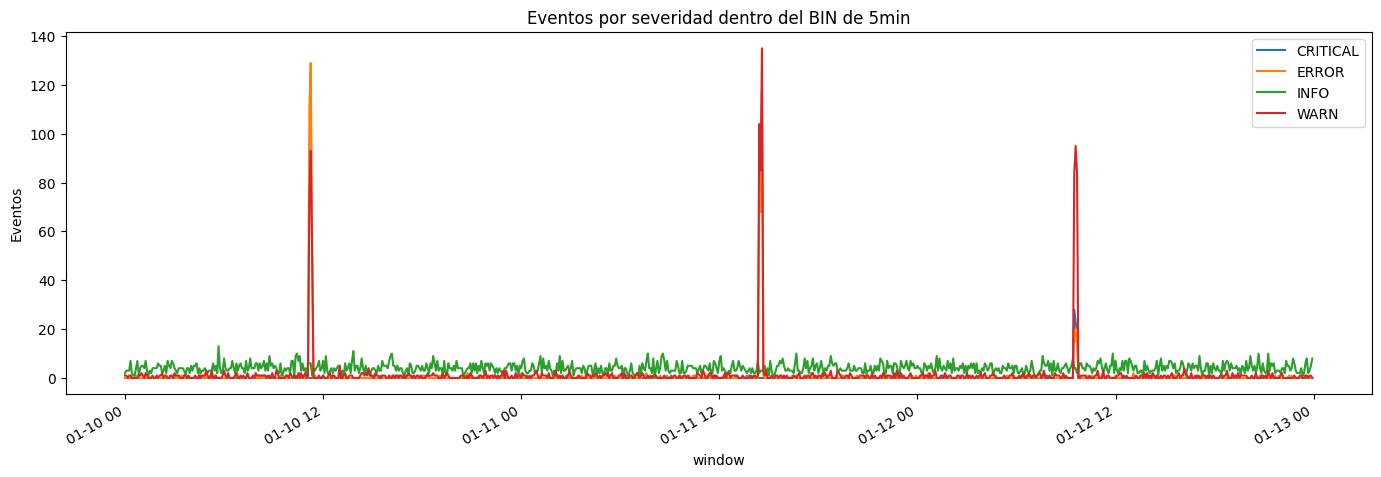

In [ ]:
columnas = df.groupby('window')['severity'].value_counts().unstack().fillna(0).round(2)
plt.figure(figsize=(14, 5))
plt.title("Eventos por severidad dentro del BIN de 5min")
plt.xlabel("Timeline")
plt.ylabel("Eventos")
plt.xticks(rotation=45)
plt.tight_layout()
columnas.plot(ax=plt.gca())
plt.legend(loc='upper right')

In [ ]:
# - Usar la tabla de bins ya calculada
# - Graficar bad_rate o %_5xx por ventana temporal
# - Marcar visualmente el momento crítico si podés